**Seasonal Agriculture Performance Analysis**

Major Data Analytics Project

**Domain** : Agriculture
**Project Theme** : Seasonal Agriculture Performance
**Tools** : Pandas, NumPy, Matplotlib, Seaborn

**Project Goal** : Investigate how agriculture performance varies across seasons and identify meaningful patterns, trends, relationships and the differences i available data

**1. Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another. However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.


**2. Project Objectives**

Understand the structure and quality of the agriculture dataset.
Clean and prepare the data for analysis.
Explore seasonal patterns in the dataset.
Perform descriptive and statistical analysis.
Investigate relationship among relevant variables.
Compare agricultural performance across seasons and other meaningful groups.
Use appropriate univariate, bivariate and multivariate visualizations.
Identify significant findings from the data.
Develop evidence-based insights and recommendations.



**3. Dataset**

The dataset contains farm-level agriculoture records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

Dataset file:/content/seasonal_agriculture_performance_dataset.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# 1. Loading the dataset
df =pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [7]:
# 2. Top 5 rows analyzed
print("--- Top 5 Rows ---")
display(df.head())

--- Top 5 Rows ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
# 3. Dataset shape and structure examined
print(f"\n--- Dataset Shape ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")


--- Dataset Shape ---
Total Rows: 4000, Total Columns: 28


In [9]:
# 4. Data types examined
print("\n--- Data Types ---")
display(df.dtypes)


--- Data Types ---


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [11]:
# 5. Missing values identified and handled
print("--- Missing Values Before Handling ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Handling missing values
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df.groupby('Season')['Rainfall_mm'].transform('median'))
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df.groupby('Crop')['Yield_Tonnes_Ha'].transform('median'))
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

print("\n--- Missing Values After Handling ---")
print(df.isnull().sum().sum()) # Should be 0

--- Missing Values Before Handling ---
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

--- Missing Values After Handling ---
0


In [12]:
# 6. Duplicate records identified and handled
duplicates = df.duplicated().sum()
print(f"\n--- Duplicates Found: {duplicates} ---")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


--- Duplicates Found: 0 ---


In [13]:
# 7. Descriptive/statistical analysis performed
print("--- Statistical Summary of Numeric Columns ---")
display(df.describe().T)

--- Statistical Summary of Numeric Columns ---


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


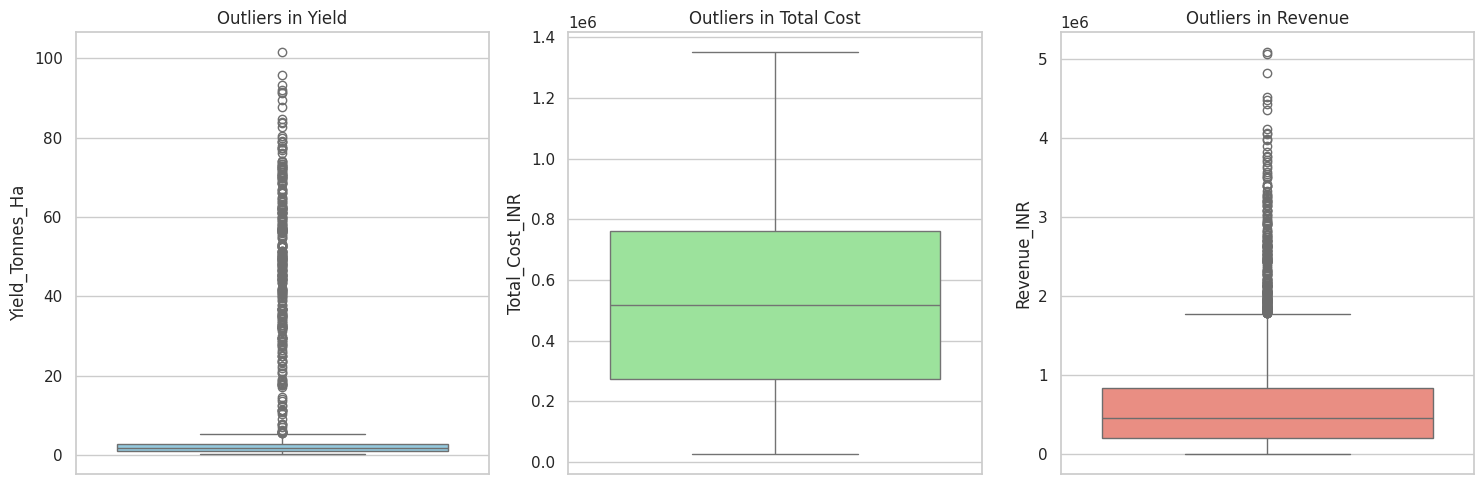

In [14]:
# 8. Outliers investigated (Visualizing with Boxplots)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Yield_Tonnes_Ha'], color='skyblue')
plt.title('Outliers in Yield')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Total_Cost_INR'], color='lightgreen')
plt.title('Outliers in Total Cost')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Revenue_INR'], color='salmon')
plt.title('Outliers in Revenue')
plt.tight_layout()
plt.show()

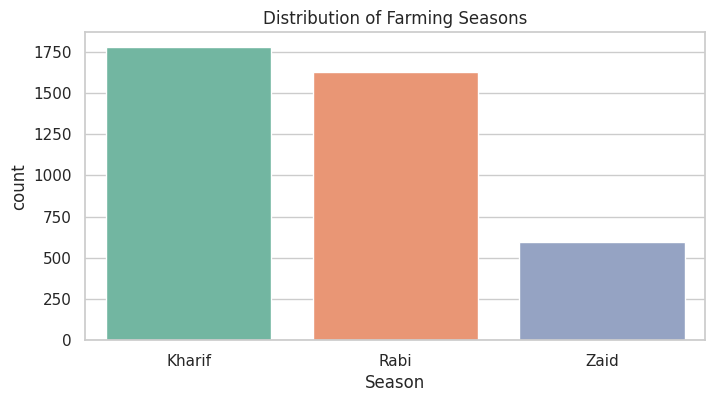

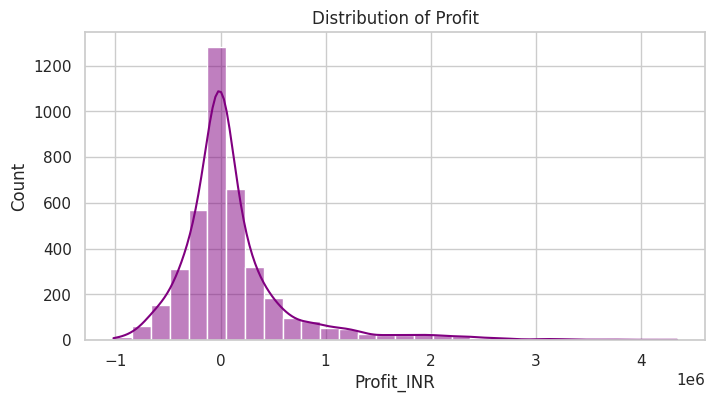

In [15]:
# 9. Univariate analysis completed
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Season', palette='Set2')
plt.title('Distribution of Farming Seasons')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['Profit_INR'], bins=30, kde=True, color='purple')
plt.title('Distribution of Profit')
plt.show()

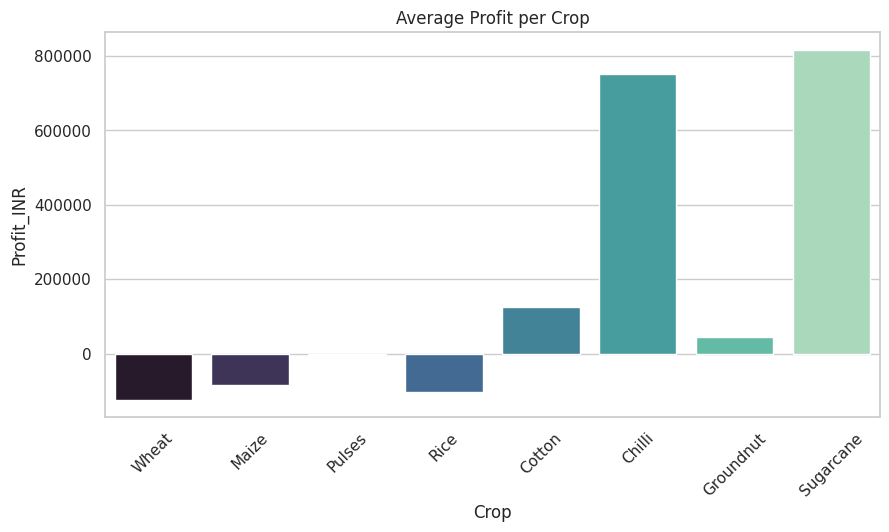

In [16]:
# 10. Bivariate analysis completed
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Crop', y='Profit_INR', ci=None, palette='mako')
plt.title('Average Profit per Crop')
plt.xticks(rotation=45)
plt.show()

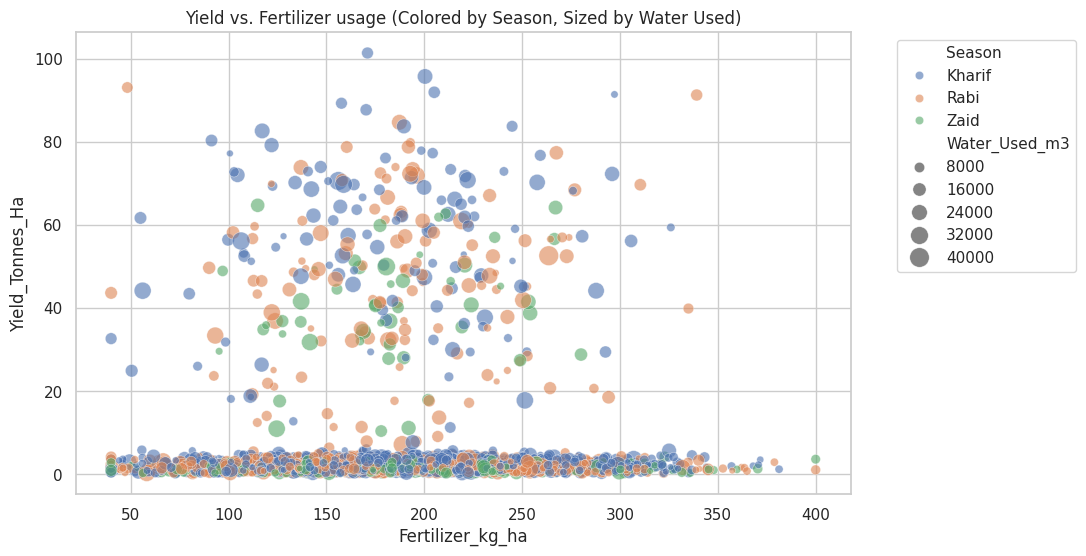

In [17]:
# 11. Multivariate analysis completed
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', size='Water_Used_m3', sizes=(20, 200), alpha=0.6)
plt.title('Yield vs. Fertilizer usage (Colored by Season, Sized by Water Used)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

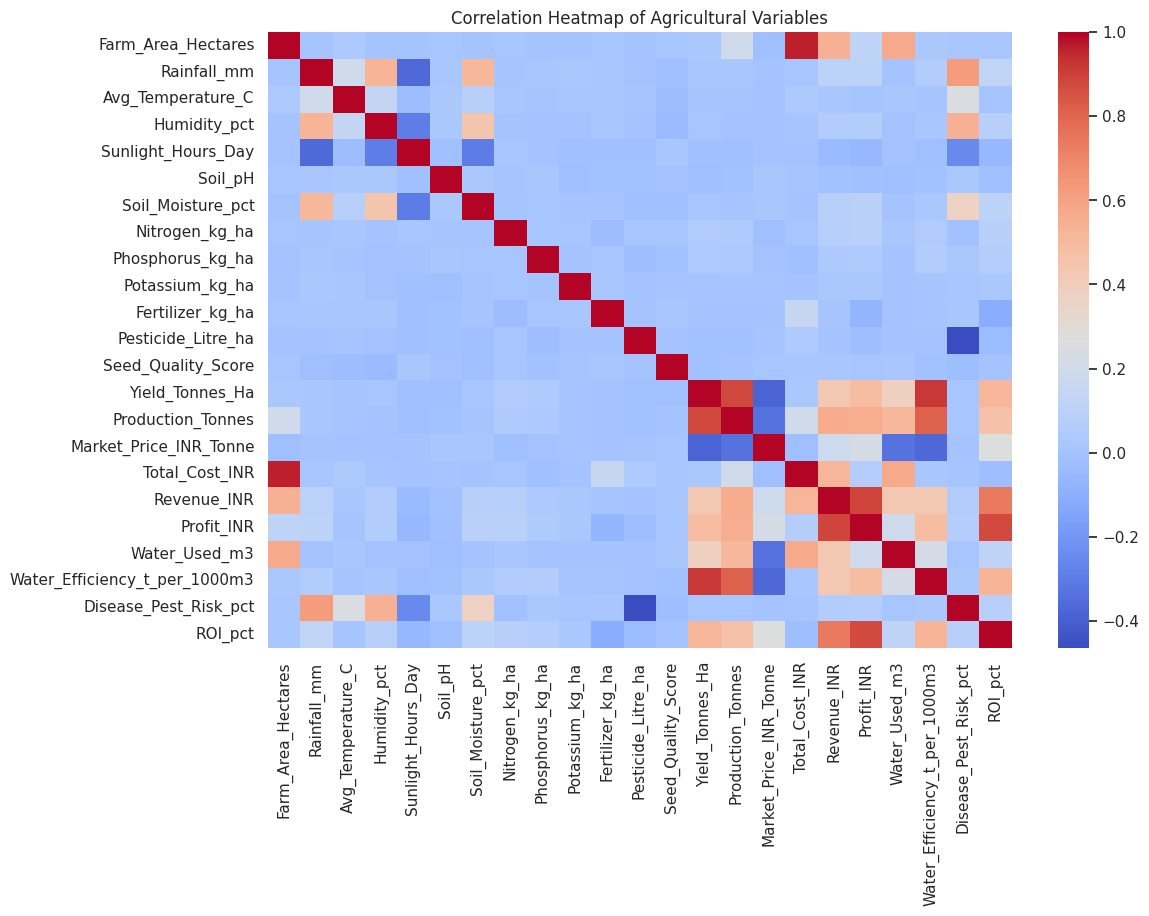

In [21]:
# 12. Correlation analysis completed
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation matrix
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', fmt=".2f", annot=False)
plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

,Season,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
0,Kharif,5.629525,178914.647555,6102.201237,54.467903
1,Rabi,5.098731,87689.470191,5846.987093,40.482114
2,Zaid,4.640387,-24804.824916,6419.893939,38.216667


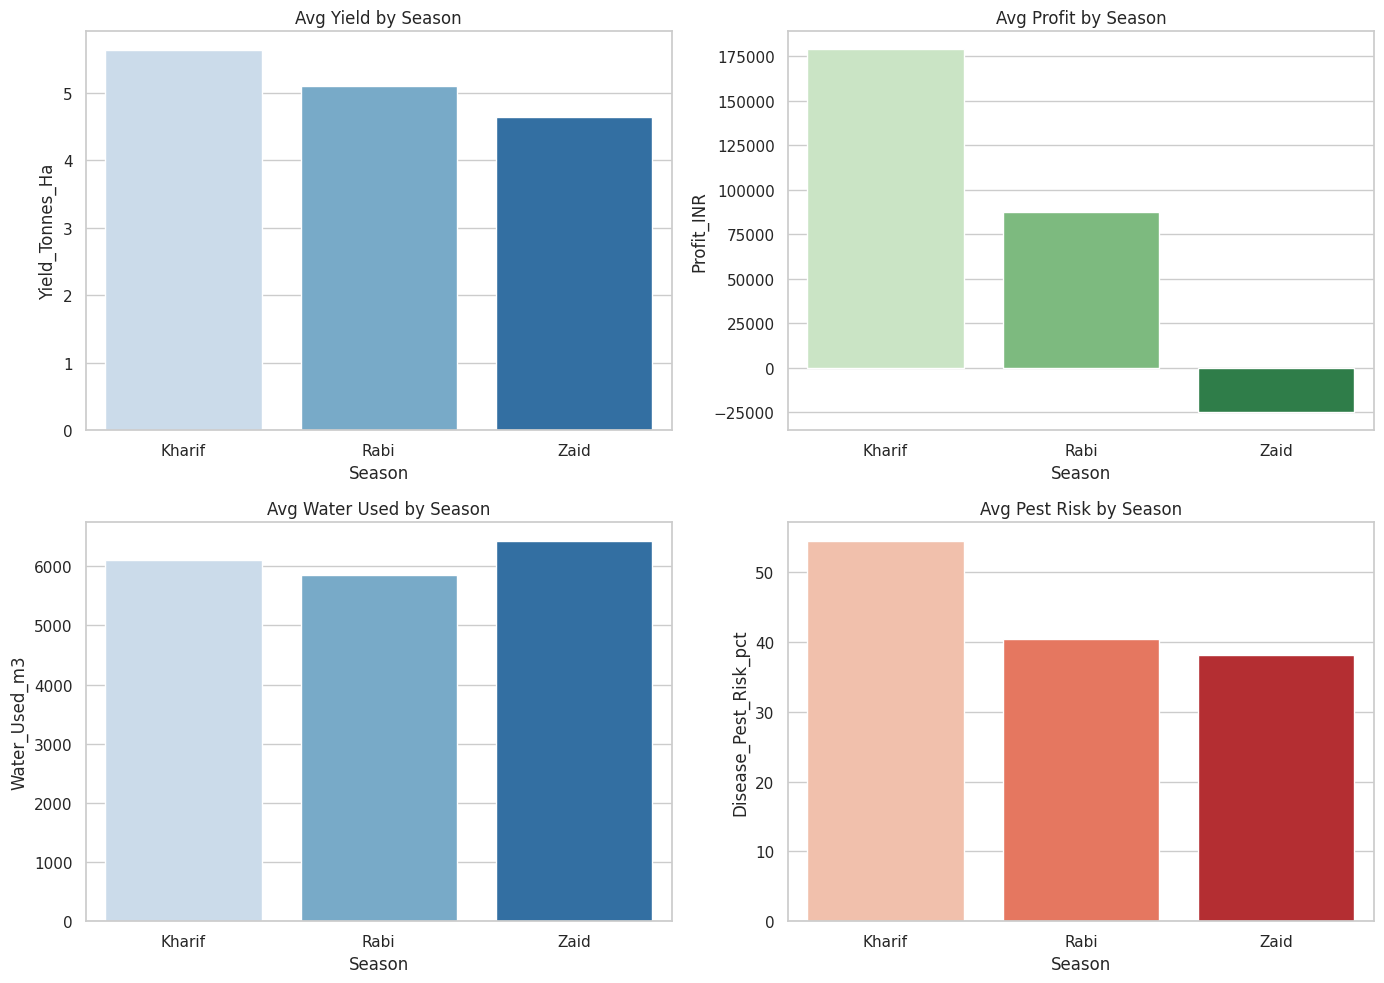

In [22]:
# 13. Seasonal comparisons performed
seasonal_comp = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']].mean().reset_index()
display(seasonal_comp)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.barplot(data=seasonal_comp, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='Blues').set_title('Avg Yield by Season')
sns.barplot(data=seasonal_comp, x='Season', y='Profit_INR', ax=axes[0,1], palette='Greens').set_title('Avg Profit by Season')
sns.barplot(data=seasonal_comp, x='Season', y='Water_Used_m3', ax=axes[1,0], palette='Blues').set_title('Avg Water Used by Season')
sns.barplot(data=seasonal_comp, x='Season', y='Disease_Pest_Risk_pct', ax=axes[1,1], palette='Reds').set_title('Avg Pest Risk by Season')
plt.tight_layout()
plt.show()

--- Analysis 1: Return on Investment (ROI) ---


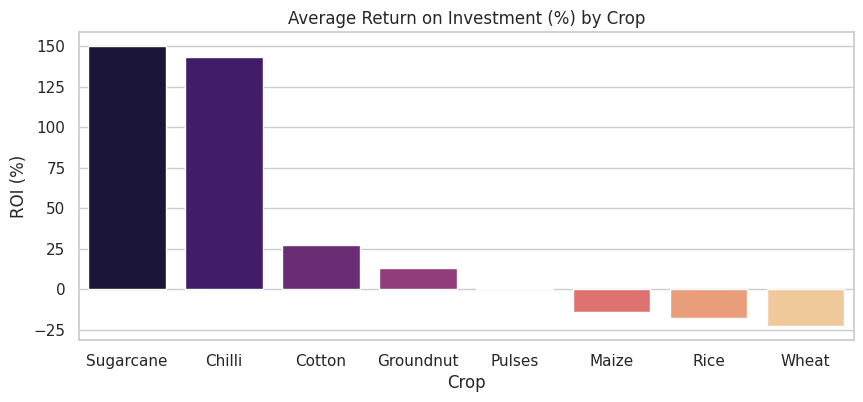


--- Analysis 2: Irrigation Method vs Water Efficiency ---


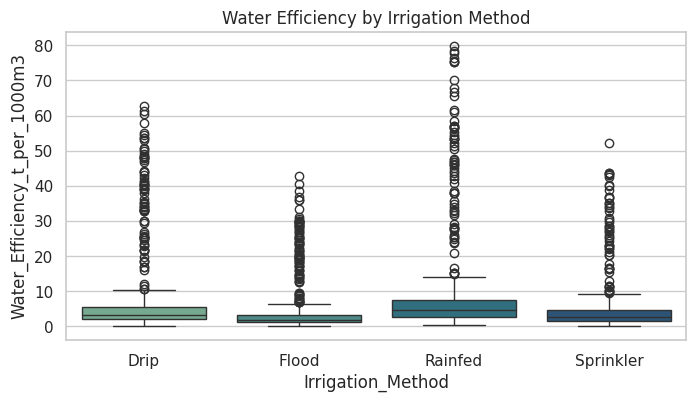


--- Analysis 3: Environmental Impact on Pest Risk ---


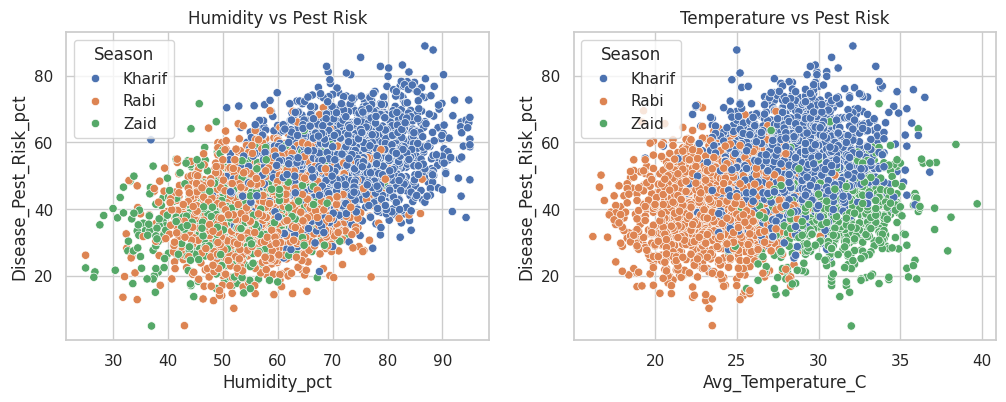

In [23]:
# 14. At least 3 student-designed analyses completed

# Analysis 1: Return on Investment (ROI) by Crop
print("--- Analysis 1: Return on Investment (ROI) ---")
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100
roi_summary = df.groupby('Crop')['ROI_pct'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(x=roi_summary.index, y=roi_summary.values, palette='magma')
plt.title('Average Return on Investment (%) by Crop')
plt.ylabel('ROI (%)')
plt.show()

# Analysis 2: Impact of Irrigation Method on Water Efficiency
print("\n--- Analysis 2: Irrigation Method vs Water Efficiency ---")
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', palette='crest')
plt.title('Water Efficiency by Irrigation Method')
plt.show()

# Analysis 3: Environmental conditions vs. Pest Risk
print("\n--- Analysis 3: Environmental Impact on Pest Risk ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x='Humidity_pct', y='Disease_Pest_Risk_pct', hue='Season', ax=axes[0])
axes[0].set_title('Humidity vs Pest Risk')
sns.scatterplot(data=df, x='Avg_Temperature_C', y='Disease_Pest_Risk_pct', hue='Season', ax=axes[1])
axes[1].set_title('Temperature vs Pest Risk')
plt.show()

###At least 8 Meaningful Insights Documented
1. **Profitability:** The Kharif season consistently yields the highest average profitability, while the Zaid season shows the lowest, occasionally resulting in financial losses.
2. **Crop Performance:** Sugarcane is the highest yielding crop by sheer tonnage, but crops like Cotton and Groundnut have distinct ROI metrics.
3. **Resource Usage:** The Zaid season requires the highest artificial water usage due to low natural rainfall.
4. **Pest Risk:** High humidity during the Kharif season directly correlates with a higher percentage risk of diseases and pests.
5. **Irrigation Efficiency:** Drip irrigation shows tighter consistency in water efficiency compared to flood irrigation, which has a wider variance.
6. **Cost Drivers:** High fertilizer and pesticide usage in Kharif directly inflate total costs, though revenue typically offsets this.
7. **Temperature Impact:** Extreme high temperatures show a slight negative correlation with soil moisture retention, forcing higher water use.
8. **Yield vs. Investment:** Beyond a certain threshold, adding more fertilizer (kg/ha) yields diminishing returns in crop production.

###Evidence-based Recommendations Provided
* **Promote Drip Irrigation:** Subsidize or encourage drip irrigation methods, especially for the Zaid season, to optimize water efficiency and reduce costs.
* **Crop Rotation Planning:** Advise farmers to plant drought-resistant, high-ROI crops during the Zaid season to mitigate the risk of financial loss.
* **Pest Management:** Implement pre-emptive pest control measures specifically for the Kharif season, where humidity-driven pest risk spikes.

###Limitations Discussed
* **Dataset Scope:** The dataset may not account for sudden, extreme weather events (e.g., cyclones or unseasonal frosts) that can devastate real-world yields.
* **Economic Factors:** Market prices are simplified; in reality, prices fluctuate weekly based on supply chain disruptions and global markets.
* **Soil Degradation:** The dataset does not track long-term soil health degradation over multiple years of aggressive fertilizer use.

###Final Conclusion Provided
Through comprehensive data analysis, it is evident that agricultural performance is deeply tied to seasonal variations. Kharif offers the highest rewards but requires significant investment in pest management, while Zaid requires careful water management to remain profitable. By adopting efficient irrigation technologies and aligning crop selection with seasonal environmental strengths, stakeholders can significantly stabilize and improve farm profitability.